# 📊 Football Visualizations using `mplsoccer`
This notebook demonstrates how to create Radar Chart

In [2]:
import pandas as pd
from mplsoccer import Radar, FontManager, grid
import matplotlib.pyplot as plt

In [3]:
# ---- LOAD DATA ----
df = pd.read_csv("radars.csv")

In [4]:
# ---- FILTER MIDFIELDERS ----
# Your dataset uses codes like DF, FW, GK. 
# Midfielders are usually MF or CM/AM/DM depending on data.
midfield_df = df[df["Pos"].str.contains("MF", case=False, na=False)]

In [5]:
# Take any three (first 3 found)
players = midfield_df.head(3)

In [31]:
players

,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Gls,Sh,...,Dist,FK,PK,PKatt,xG,npxG,npxG/Sh,G-xG,np:G-xG,Matches
11,12,Thiago Alcántara\Thiago-Alcantara,es ESP,MF,Liverpool,29-325,1991,10.9,0,12,...,22.2,1,0,0,0.4,0.4,0.03,-0.4,-0.4,Matches
15,16,Ezgjan Alioski\Ezgjan-Alioski,mk MKD,DFMF,Leeds United,29-018,1992,16.5,2,14,...,19.2,0,0,0,1.0,1.0,0.07,1.0,1.0,Matches
17,18,Allan\Allan,br BRA,MF,Everton,30-053,1991,12.4,0,4,...,23.8,0,0,0,0.1,0.1,0.03,-0.1,-0.1,Matches


In [8]:
# ---- SELECT METRICS FOR RADAR ----
metrics = ['Gls', 'Sh', 'Dist', 'xG', 'npxG', 'npxG/Sh']

In [9]:
# Extract values
values = players[metrics].values

In [32]:
values

array([[ 0.  , 12.  , 22.2 ,  0.4 ,  0.4 ,  0.03],
       [ 2.  , 14.  , 19.2 ,  1.  ,  1.  ,  0.07],
       [ 0.  ,  4.  , 23.8 ,  0.1 ,  0.1 ,  0.03]])

In [23]:
min_range = [0 for _ in metrics]
max_range = [df[m].max() for m in metrics]

In [38]:
# ---- CREATE RADAR USING CORRECT SIGNATURE ----
radar = Radar(
    params=metrics,
    min_range=min_range,
    max_range=max_range,
    round_int=[False]*len(metrics),
    num_rings=4,  # the number of concentric circles (excluding center circle)
    # if the ring_width is more than the center_circle_radius then
    # the center circle radius will be wider than the width of the concentric circles
    ring_width=1, center_circle_radius=1,
)


# Player 1 Radar chart with Title, labels and spokes

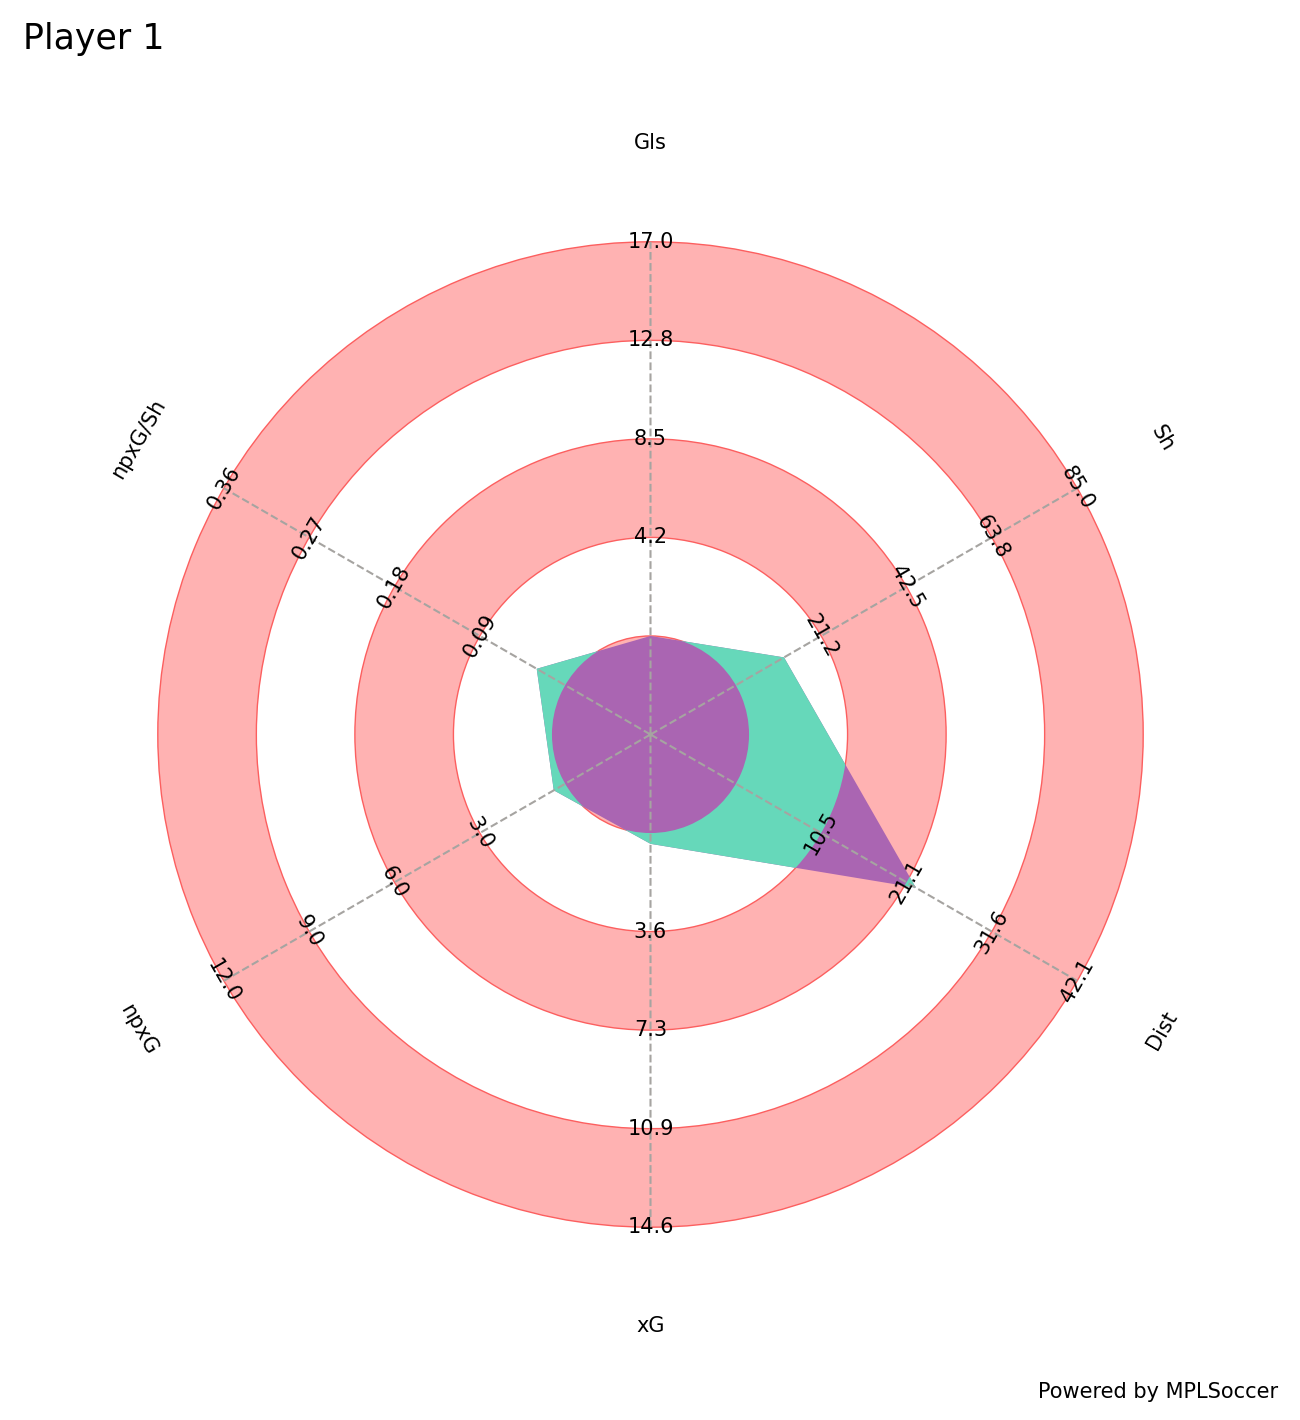

In [40]:
# creating the figure using the grid function from mplsoccer:
fig, axs = grid(figheight=14, grid_height=0.915, title_height=0.06, endnote_height=0.025,
                title_space=0, endnote_space=0, grid_key='radar', axis=False)
#plot the radar
radar.setup_axis(ax=axs['radar'])  # format axis as a radar
rings_inner = radar.draw_circles(ax=axs['radar'], facecolor='#ffb2b2', edgecolor='#fc5f5f')  # draw circles
radar_output = radar.draw_radar(values[0], ax=axs['radar'], 
                                kwargs_radar={'facecolor': '#aa65b2'},
                                kwargs_rings={'facecolor': '#66d8ba'})  # draw the radar
range_labels = radar.draw_range_labels(ax=axs['radar'], fontsize=15)  # draw the range labels
param_labels = radar.draw_param_labels(ax=axs['radar'], fontsize=15)  # draw the param labels
lines = radar.spoke(ax=axs['radar'], color='#a6a4a1', linestyle='--', zorder=2)
title1_text = axs['title'].text(0.01, 0.65, 'Player 1', fontsize=25,
                                ha='left', va='center')
endnote_text = axs['endnote'].text(0.99, 0.5, 'Powered by MPLSoccer', fontsize=15,
                                   ha='right', va='center')

# Comparing Three Players

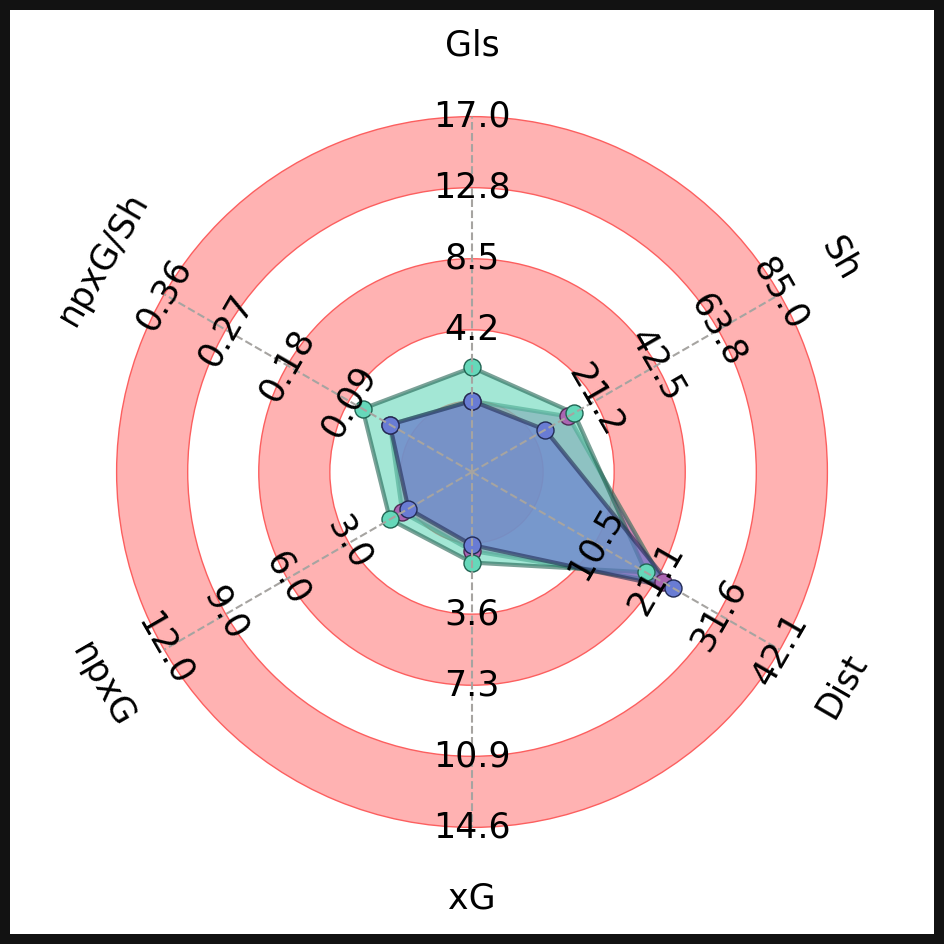

In [ ]:
# plot radar
fig, ax = radar.setup_axis()
rings_inner = radar.draw_circles(ax=ax, facecolor='#ffb2b2', edgecolor='#fc5f5f')

radar1, vertices1 = radar.draw_radar_solid(values[0], ax=ax,
                                           kwargs={'facecolor': '#aa65b2',
                                                   'alpha': 0.6,
                                                   'edgecolor': '#216352',
                                                   'lw': 3})

radar2, vertices2 = radar.draw_radar_solid(values[1], ax=ax,
                                           kwargs={'facecolor': '#66d8ba',
                                                   'alpha': 0.6,
                                                   'edgecolor': '#216352',
                                                   'lw': 3})

radar3, vertices3 = radar.draw_radar_solid(values[2], ax=ax,
                                           kwargs={'facecolor': '#697cd4',
                                                   'alpha': 0.6,
                                                   'edgecolor': '#222b54',
                                                   'lw': 3})

ax.scatter(vertices1[:, 0], vertices1[:, 1],
           c='#aa65b2', edgecolors='#502a54', marker='o', s=150, zorder=2)
ax.scatter(vertices2[:, 0], vertices2[:, 1],
           c='#66d8ba', edgecolors='#216352', marker='o', s=150, zorder=2)
ax.scatter(vertices3[:, 0], vertices3[:, 1],
           c='#697cd4', edgecolors='#222b54', marker='o', s=150, zorder=2)

range_labels = radar.draw_range_labels(ax=ax, fontsize=25)
param_labels = radar.draw_param_labels(ax=ax, fontsize=25)
lines = radar.spoke(ax=ax, color='#a6a4a1', linestyle='--', zorder=2)
fig.set_facecolor('#121212') # black outline